# Notebook 04: LSTM with Attention Mechanism

## Objective
Build and train an LSTM model with Bahdanau-style attention mechanism to:
1. Improve prediction accuracy over baseline LSTM
2. Provide interpretable attention weights showing temporal importance
3. Enable farmers to understand which historical timesteps influence predictions

## Attention Mechanism Benefits
- **Interpretability**: Attention weights show which past timesteps are important
- **Performance**: Model can focus on relevant temporal patterns
- **Trust**: Farmers can validate that model focuses on agronomically relevant periods

## Expected Outcomes
- Attention-LSTM model with comparable or better accuracy than baseline
- Saved attention weights for visualization
- Performance comparison metrics

## 1. Import Libraries

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")
print("✅ Libraries imported successfully!")

TensorFlow version: 2.20.0
Keras version: 3.12.0
✅ Libraries imported successfully!


## 2. Load Preprocessed Data

In [19]:
# Define paths
results_dir = Path('../results')
models_dir = results_dir / 'models'
figures_dir = results_dir / 'figures'
tables_dir = results_dir / 'tables'

# Load preprocessed data
X_train = np.load(results_dir / 'X_train.npy')
X_test = np.load(results_dir / 'X_test.npy')
y_train = np.load(results_dir / 'y_train.npy')
y_test = np.load(results_dir / 'y_test.npy')

# Create validation split from training data (10%)
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.1, random_state=42
)

# Load feature names
with open(results_dir / 'feature_names.pkl', 'rb') as f:
    feature_names = pickle.load(f)

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"Features: {feature_names}")
print("\n✅ Data loaded successfully!")

X_train shape: (682319, 15, 6)
X_val shape: (75814, 15, 6)
X_test shape: (189534, 15, 6)
Features: ['humidity', 'temperature', 'humiditysol', 'temperaturesol', 'co2', 'lumière']

✅ Data loaded successfully!


## 3. Define Attention Layer

Implementing Bahdanau-style attention mechanism:
- Computes attention scores for each timestep
- Applies softmax to get attention weights (sum to 1)
- Creates context vector as weighted sum of LSTM outputs
- Returns both context and attention weights for interpretability

In [20]:
class AttentionLayer(layers.Layer):
    """
    Bahdanau-style attention mechanism for time series.
    
    Args:
        units: Number of hidden units in attention mechanism
        return_sequences: If True, return attention weights for all samples
    
    Returns:
        context_vector: Weighted sum of input sequences
        attention_weights: Attention scores for each timestep (for interpretation)
    """
    
    def __init__(self, units=20, return_sequences=True, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)
        self.units = units
        self.return_sequences = return_sequences
    
    def build(self, input_shape):
        # Input shape: (batch_size, timesteps, features)
        self.W = self.add_weight(
            name='attention_weight',
            shape=(input_shape[-1], self.units),
            initializer='glorot_uniform',
            trainable=True
        )
        self.b = self.add_weight(
            name='attention_bias',
            shape=(self.units,),
            initializer='zeros',
            trainable=True
        )
        self.u = self.add_weight(
            name='attention_vector',
            shape=(self.units,),
            initializer='glorot_uniform',
            trainable=True
        )
        super(AttentionLayer, self).build(input_shape)
    
    def call(self, inputs):
        # inputs shape: (batch_size, timesteps, features)
        
        # Calculate attention scores
        # score = tanh(W * h + b)
        score = tf.nn.tanh(tf.tensordot(inputs, self.W, axes=1) + self.b)
        
        # Calculate attention weights
        # attention_weights = softmax(u * score)
        attention_weights = tf.nn.softmax(
            tf.tensordot(score, self.u, axes=1), axis=1
        )
        
        # Reshape attention weights for multiplication
        attention_weights = tf.expand_dims(attention_weights, axis=-1)
        
        # Calculate context vector (weighted sum)
        context_vector = tf.reduce_sum(inputs * attention_weights, axis=1)
        
        if self.return_sequences:
            return context_vector, tf.squeeze(attention_weights, axis=-1)
        else:
            return context_vector
    
    def get_config(self):
        config = super().get_config()
        config.update({
            'units': self.units,
            'return_sequences': self.return_sequences
        })
        return config

print("✅ Attention layer defined!")

✅ Attention layer defined!


## 4. Build Attention-LSTM Model

In [21]:
def build_attention_lstm(input_shape, lstm_units=20, attention_units=20):
    """
    Build LSTM model with attention mechanism.
    
    Architecture:
    - Input layer
    - LSTM layer (return sequences for attention)
    - Attention layer (computes weighted context)
    - Dense output layer
    
    Args:
        input_shape: (timesteps, features)
        lstm_units: Number of LSTM units
        attention_units: Number of attention hidden units
    
    Returns:
        model: Compiled Keras model
        attention_model: Model for extracting attention weights
    """
    # Define inputs
    inputs = Input(shape=input_shape, name='input_sequences')
    
    # LSTM layer (must return sequences for attention)
    lstm_output = layers.LSTM(
        lstm_units,
        return_sequences=True,
        name='lstm_layer'
    )(inputs)
    
    # Attention layer
    context_vector, attention_weights = AttentionLayer(
        units=attention_units,
        return_sequences=True,
        name='attention_layer'
    )(lstm_output)
    
    # Output layer
    outputs = layers.Dense(1, name='output_layer')(context_vector)
    
    # Create models
    model = Model(inputs=inputs, outputs=outputs, name='attention_lstm')
    attention_model = Model(inputs=inputs, outputs=attention_weights, name='attention_weights_extractor')
    
    # Compile model
    model.compile(
        optimizer='adam',
        loss='mse',
        metrics=['mae']
    )
    
    return model, attention_model

# Build the model
timesteps, n_features = X_train.shape[1], X_train.shape[2]
model, attention_model = build_attention_lstm(
    input_shape=(timesteps, n_features),
    lstm_units=20,
    attention_units=20
)

print("\n" + "="*60)
print("ATTENTION-LSTM MODEL ARCHITECTURE")
print("="*60)
model.summary()
print("\n✅ Model built successfully!")


ATTENTION-LSTM MODEL ARCHITECTURE


Model: "attention_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_sequences (InputLayer)    │ (None, 15, 6)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_layer (LSTM)               │ (None, 15, 20)         │         2,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention_layer                 │ [(None, 20), (None,    │           440 │
│ (AttentionLayer)                │ 15)]                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,621 (10.24 KB)

 Trainable params: 2,621 (10.24 KB)

 Non-trainable params: 0 (0.00 B)


✅ Model built successfully!


## 5. Train Attention-LSTM Model

In [22]:
# Define callbacks
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=str(models_dir / 'attention_lstm_best.h5'),
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
]

print("Starting training...")
print("This may take 20-30 minutes depending on hardware.\n")

# Train the model
history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=50,
    batch_size=80,
    callbacks=callbacks,
    verbose=1
)

print("\n✅ Training complete!")

Starting training...
This may take 20-30 minutes depending on hardware.

Epoch 1/50
Epoch 1/50
7651/7677 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0030 - mae: 0.0106
Epoch 1: val_loss improved from None to 0.00001, saving model to ../results/models/attention_lstm_best.h5

Epoch 1: val_loss improved from None to 0.00001, saving model to ../results/models/attention_lstm_best.h5


7677/7677 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - loss: 4.4321e-04 - mae: 0.0033 - val_loss: 9.7903e-06 - val_mae: 0.0024 - learning_rate: 0.0010
Epoch 2/50
Epoch 2/50
7666/7677 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.1204e-05 - mae: 0.0020
Epoch 2: val_loss improved from 0.00001 to 0.00001, saving model to ../results/models/attention_lstm_best.h5

Epoch 2: val_loss improved from 0.00001 to 0.00001, saving model to ../results/models/attention_lstm_best.h5


7677/7677 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - loss: 1.1827e-05 - mae: 0.0019 - val_loss: 5.8493e-06 - val_mae: 0.0016 - learning_rate: 0.0010
Epoch 3/50
Epoch 3/50
7657/7677 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 9.2082e-06 - mae: 0.0018
Epoch 3: val_loss did not improve from 0.00001
7677/7677 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - loss: 1.0793e-05 - mae: 0.0018 - val_loss: 1.3208e-05 - val_mae: 0.0030 - learning_rate: 0.0010
Epoch 4/50

Epoch 3: val_loss did not improve from 0.00001
7677/7677 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - loss: 1.0793e-05 - mae: 0.0018 - val_loss: 1.3208e-05 - val_mae: 0.0030 - learning_rate: 0.0010
Epoch 4/50
7671/7677 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8.9703e-06 - mae: 0.0018
Epoch 4: val_loss improved from 0.00001 to 0.00001, saving model to ../results/models/attention_lstm_best.h5

Epoch 4: val_loss improved from 0.00001 to 0.00001, saving model to ../results/models/attention_lstm_best.h5


7677/7677 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - loss: 1.0417e-05 - mae: 0.0018 - val_loss: 5.2959e-06 - val_mae: 0.0014 - learning_rate: 0.0010
Epoch 5/50
Epoch 5/50
7673/7677 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0486e-05 - mae: 0.0018
Epoch 5: val_loss did not improve from 0.00001
7677/7677 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - loss: 1.0028e-05 - mae: 0.0018 - val_loss: 1.1758e-05 - val_mae: 0.0028 - learning_rate: 0.0010
Epoch 6/50

Epoch 5: val_loss did not improve from 0.00001
7677/7677 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - loss: 1.0028e-05 - mae: 0.0018 - val_loss: 1.1758e-05 - val_mae: 0.0028 - learning_rate: 0.0010
Epoch 6/50
7674/7677 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.2450e-05 - mae: 0.0018
Epoch 6: val_loss did not improve from 0.00001

Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
7677/7677 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - loss: 9.6262e-06 - mae: 0.0017 - val_loss: 1.3920e-05 - val_mae: 0.0031 - learning_rate: 0.0010
Epoch 7/50

Epoch

7677/7677 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - loss: 7.8437e-06 - mae: 0.0016 - val_loss: 4.2178e-06 - val_mae: 0.0014 - learning_rate: 5.0000e-04
Epoch 9/50
Epoch 9/50
7649/7677 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.2404e-05 - mae: 0.0016
Epoch 9: val_loss did not improve from 0.00000
7677/7677 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - loss: 7.5655e-06 - mae: 0.0016 - val_loss: 9.4827e-06 - val_mae: 0.0026 - learning_rate: 5.0000e-04
Epoch 10/50

Epoch 9: val_loss did not improve from 0.00000
7677/7677 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - loss: 7.5655e-06 - mae: 0.0016 - val_loss: 9.4827e-06 - val_mae: 0.0026 - learning_rate: 5.0000e-04
Epoch 10/50
7671/7677 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.4793e-06 - mae: 0.0016
Epoch 10: val_loss did not improve from 0.00000
7677/7677 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - loss: 7.3638e-06 - mae: 0.0016 - val_loss: 4.8642e-06 - val_mae: 0.0017 - learning_rate: 5.0000e-04
Epoch 11/50

Epoch 10: val_loss did not improve from 0.00000
7677/7677 ━━━━

...

7677/7677 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - loss: 5.6643e-06 - mae: 0.0014 - val_loss: 3.7516e-06 - val_mae: 0.0013 - learning_rate: 1.5625e-05
Epoch 33/50
Epoch 33/50
7673/7677 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5.2823e-06 - mae: 0.0014
Epoch 33: val_loss improved from 0.00000 to 0.00000, saving model to ../results/models/attention_lstm_best.h5

Epoch 33: val_loss improved from 0.00000 to 0.00000, saving model to ../results/models/attention_lstm_best.h5


7677/7677 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - loss: 5.6605e-06 - mae: 0.0014 - val_loss: 3.7511e-06 - val_mae: 0.0013 - learning_rate: 1.5625e-05
Epoch 34/50
Epoch 34/50
7664/7677 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2073e-06 - mae: 0.0014
Epoch 34: val_loss did not improve from 0.00000
7677/7677 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - loss: 5.6581e-06 - mae: 0.0014 - val_loss: 3.7874e-06 - val_mae: 0.0014 - learning_rate: 1.5625e-05
Epoch 35/50
7656/7677 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5.7735e-06 - mae: 0.0014
Epoch 35: val_loss did not improve from 0.00000
7677/7677 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - loss: 5.6419e-06 - mae: 0.0014 - val_loss: 3.7651e-06 - val_mae: 0.0013 - learning_rate: 1.5625e-05
Epoch 36/50
7662/7677 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5.6826e-06 - mae: 0.0014
Epoch 36: val_loss did not improve from 0.00000

Epoch 36: ReduceLROnPlateau reducing learning rate to 7.812500371073838e-06.
7677/7677 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - loss: 5.6535e-06 -

7677/7677 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - loss: 5.5974e-06 - mae: 0.0013 - val_loss: 3.7451e-06 - val_mae: 0.0013 - learning_rate: 3.9063e-06
Epoch 43/50
Epoch 43/50
7671/7677 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.5764e-06 - mae: 0.0013
Epoch 43: val_loss improved from 0.00000 to 0.00000, saving model to ../results/models/attention_lstm_best.h5

Epoch 43: val_loss improved from 0.00000 to 0.00000, saving model to ../results/models/attention_lstm_best.h5


7677/7677 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - loss: 5.5954e-06 - mae: 0.0013 - val_loss: 3.7446e-06 - val_mae: 0.0013 - learning_rate: 3.9063e-06
Epoch 44/50
Epoch 44/50
7674/7677 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5.2805e-06 - mae: 0.0013
Epoch 44: val_loss improved from 0.00000 to 0.00000, saving model to ../results/models/attention_lstm_best.h5

Epoch 44: val_loss improved from 0.00000 to 0.00000, saving model to ../results/models/attention_lstm_best.h5


7677/7677 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - loss: 5.5977e-06 - mae: 0.0013 - val_loss: 3.7429e-06 - val_mae: 0.0013 - learning_rate: 3.9063e-06
Epoch 45/50
Epoch 45/50
7654/7677 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5.5209e-06 - mae: 0.0013
Epoch 45: val_loss did not improve from 0.00000
7677/7677 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - loss: 5.5968e-06 - mae: 0.0013 - val_loss: 3.7556e-06 - val_mae: 0.0013 - learning_rate: 3.9063e-06
Epoch 46/50

Epoch 45: val_loss did not improve from 0.00000
7677/7677 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - loss: 5.5968e-06 - mae: 0.0013 - val_loss: 3.7556e-06 - val_mae: 0.0013 - learning_rate: 3.9063e-06
Epoch 46/50
7662/7677 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.1215e-05 - mae: 0.0013
Epoch 46: val_loss did not improve from 0.00000

Epoch 46: ReduceLROnPlateau reducing learning rate to 1.9531250927684596e-06.
7677/7677 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - loss: 5.5964e-06 - mae: 0.0013 - val_loss: 3.7498e-06 - val_mae: 0.0013 - learning_rate: 3.9

## 6. Evaluate Model Performance

In [23]:
# Make predictions
y_train_pred = model.predict(X_train, verbose=0)
y_test_pred = model.predict(X_test, verbose=0)

# Calculate metrics
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("="*60)
print("ATTENTION-LSTM MODEL PERFORMANCE")
print("="*60)
print(f"\nTraining Metrics:")
print(f"  RMSE: {train_rmse:.4f}")
print(f"  MAE:  {train_mae:.4f}")
print(f"  R²:   {train_r2:.4f}")

print(f"\nTest Metrics:")
print(f"  RMSE: {test_rmse:.4f}")
print(f"  MAE:  {test_mae:.4f}")
print(f"  R²:   {test_r2:.4f}")

# Save metrics
metrics_df = pd.DataFrame({
    'Metric': ['RMSE', 'MAE', 'R2'],
    'Train': [train_rmse, train_mae, train_r2],
    'Test': [test_rmse, test_mae, test_r2]
})
metrics_df.to_csv(tables_dir / 'attention_lstm_metrics.csv', index=False)
print("\n✅ Metrics saved!")

ATTENTION-LSTM MODEL PERFORMANCE

Training Metrics:
  RMSE: 0.0023
  MAE:  0.0013
  R²:   0.9989

Test Metrics:
  RMSE: 0.0094
  MAE:  0.0030
  R²:   0.8270

✅ Metrics saved!


## 7. Compare with Baseline LSTM

In [24]:
# Load baseline metrics
baseline_metrics = pd.read_csv(tables_dir / 'baseline_metrics.csv')

# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Model': ['Baseline LSTM', 'Attention-LSTM'],
    'Test_RMSE': [baseline_metrics['test_rmse'][0], test_rmse],
    'Test_MAE': [baseline_metrics['test_mae'][0], test_mae],
    'Test_R2': [baseline_metrics['test_r2'][0], test_r2]
})

print("="*60)
print("MODEL COMPARISON")
print("="*60)
print(comparison_df.to_string(index=False))

# Calculate improvement
rmse_diff = test_rmse - baseline_metrics['test_rmse'][0]
mae_diff = test_mae - baseline_metrics['test_mae'][0]
rmse_change_pct = (rmse_diff / baseline_metrics['test_rmse'][0]) * 100
mae_change_pct = (mae_diff / baseline_metrics['test_mae'][0]) * 100

print(f"\nChange from Baseline:")
print(f"  RMSE: {rmse_change_pct:+.2f}%")
print(f"  MAE:  {mae_change_pct:+.2f}%")

# Save comparison
comparison_df.to_csv(tables_dir / 'model_comparison.csv', index=False)
print("\n✅ Comparison saved!")

MODEL COMPARISON
         Model  Test_RMSE  Test_MAE  Test_R2
 Baseline LSTM   0.008905  0.004432 0.844162
Attention-LSTM   0.009383  0.002953 0.826988

Change from Baseline:
  RMSE: +5.37%
  MAE:  -33.37%

✅ Comparison saved!


## 8. Visualize Training History

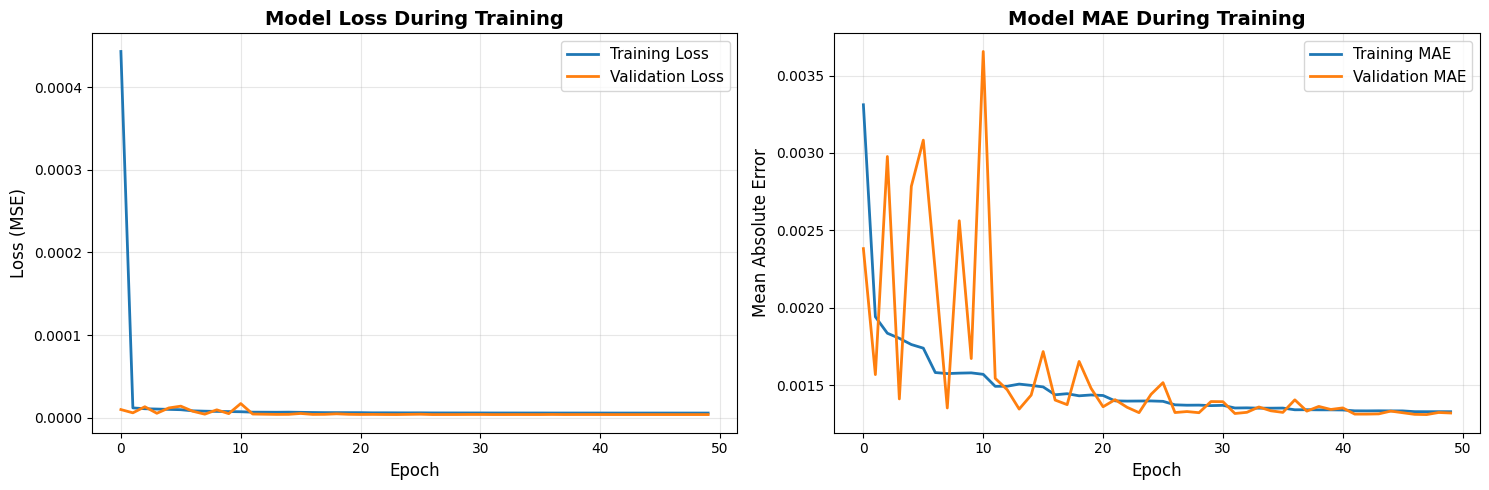

✅ Training history plotted!


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot loss
axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss (MSE)', fontsize=12)
axes[0].set_title('Model Loss During Training', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Plot MAE
axes[1].plot(history.history['mae'], label='Training MAE', linewidth=2)
axes[1].plot(history.history['val_mae'], label='Validation MAE', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Mean Absolute Error', fontsize=12)
axes[1].set_title('Model MAE During Training', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(figures_dir / 'attention_lstm_training_history.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Training history plotted!")

## 9. Visualize Predictions

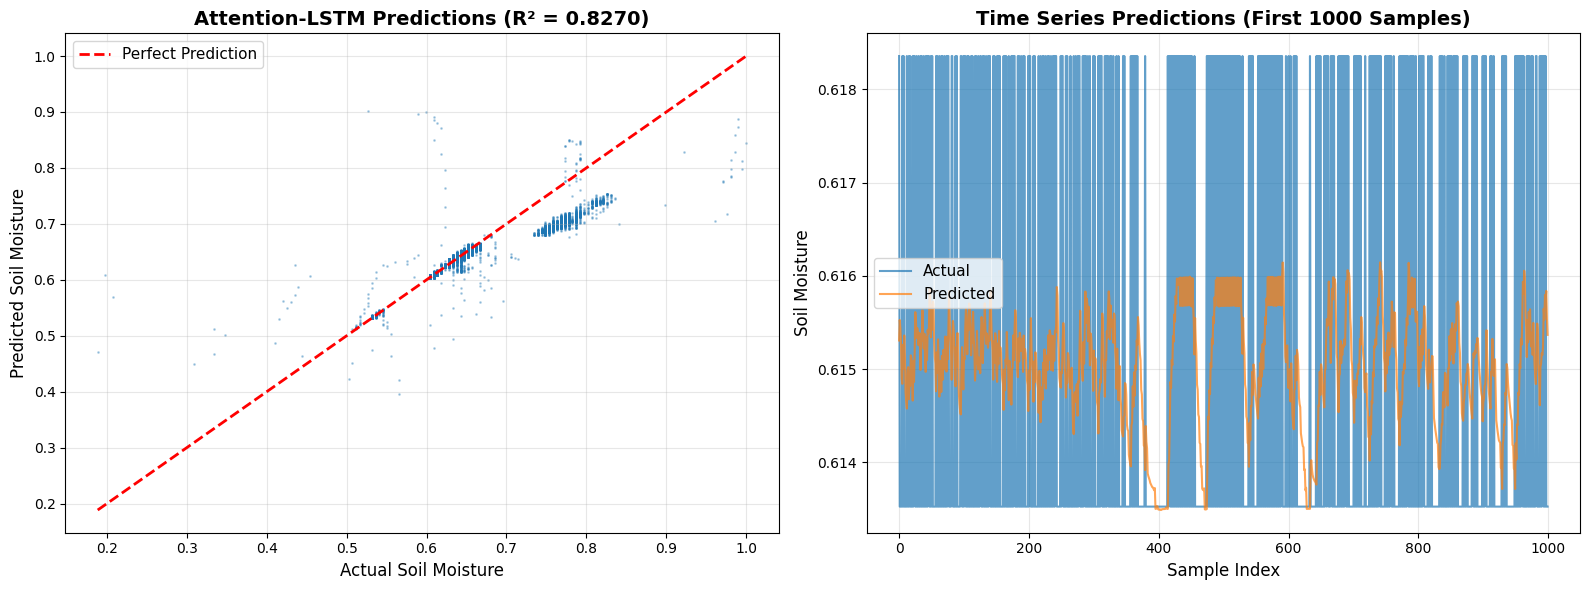

✅ Predictions visualized!


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot
axes[0].scatter(y_test, y_test_pred, alpha=0.3, s=1)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Soil Moisture', fontsize=12)
axes[0].set_ylabel('Predicted Soil Moisture', fontsize=12)
axes[0].set_title(f'Attention-LSTM Predictions (R² = {test_r2:.4f})', 
                  fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Time series plot (first 1000 samples)
sample_range = range(1000)
axes[1].plot(sample_range, y_test[:1000], label='Actual', alpha=0.7, linewidth=1.5)
axes[1].plot(sample_range, y_test_pred[:1000], label='Predicted', alpha=0.7, linewidth=1.5)
axes[1].set_xlabel('Sample Index', fontsize=12)
axes[1].set_ylabel('Soil Moisture', fontsize=12)
axes[1].set_title('Time Series Predictions (First 1000 Samples)', 
                  fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(figures_dir / 'attention_lstm_predictions.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Predictions visualized!")

## 10. Extract and Save Attention Weights

In [27]:
# Extract attention weights for test set
print("Extracting attention weights...")
attention_weights = attention_model.predict(X_test, verbose=1)

print(f"\nAttention weights shape: {attention_weights.shape}")
print(f"Expected: (n_samples={len(X_test)}, timesteps={timesteps})")

# Save attention weights
np.save(results_dir / 'attention_weights.npy', attention_weights)

# Calculate average attention across all samples
avg_attention = attention_weights.mean(axis=0)

print("\n" + "="*60)
print("AVERAGE ATTENTION WEIGHTS (across all test samples)")
print("="*60)
for t in range(timesteps):
    print(f"Timestep t-{timesteps-t}: {avg_attention[t]:.6f}")

# Save average attention
avg_attention_df = pd.DataFrame({
    'Timestep': [f't-{timesteps-i}' for i in range(timesteps)],
    'Average_Attention': avg_attention
})
avg_attention_df.to_csv(tables_dir / 'average_attention_weights.csv', index=False)

print("\n✅ Attention weights extracted and saved!")

Extracting attention weights...
5923/5923 ━━━━━━━━━━━━━━━━━━━━ 3s 511us/step
5923/5923 ━━━━━━━━━━━━━━━━━━━━ 3s 511us/step

Attention weights shape: (189534, 15)
Expected: (n_samples=189534, timesteps=15)

AVERAGE ATTENTION WEIGHTS (across all test samples)
Timestep t-15: 0.071650
Timestep t-14: 0.045728
Timestep t-13: 0.040399
Timestep t-12: 0.040981
Timestep t-11: 0.043297
Timestep t-10: 0.046097
Timestep t-9: 0.049207
Timestep t-8: 0.052883
Timestep t-7: 0.057463
Timestep t-6: 0.063325
Timestep t-5: 0.070855
Timestep t-4: 0.080680
Timestep t-3: 0.093594
Timestep t-2: 0.110621
Timestep t-1: 0.133255

✅ Attention weights extracted and saved!

Attention weights shape: (189534, 15)
Expected: (n_samples=189534, timesteps=15)

AVERAGE ATTENTION WEIGHTS (across all test samples)
Timestep t-15: 0.071650
Timestep t-14: 0.045728
Timestep t-13: 0.040399
Timestep t-12: 0.040981
Timestep t-11: 0.043297
Timestep t-10: 0.046097
Timestep t-9: 0.049207
Timestep t-8: 0.052883
Timestep t-7: 0.057463
Ti

## 11. Save Final Model

In [28]:
# Save final model
model.save(models_dir / 'attention_lstm_final.h5')
attention_model.save(models_dir / 'attention_extractor.h5')

# Save predictions
np.save(results_dir / 'y_train_pred_attention.npy', y_train_pred)
np.save(results_dir / 'y_test_pred_attention.npy', y_test_pred)

print("✅ Models and predictions saved!")
print(f"\nSaved files:")
print(f"  - attention_lstm_best.h5 (best model during training)")
print(f"  - attention_lstm_final.h5 (final trained model)")
print(f"  - attention_extractor.h5 (for extracting attention weights)")
print(f"  - attention_weights.npy (all test set attention weights)")
print(f"  - average_attention_weights.csv (mean attention per timestep)")
print(f"  - attention_lstm_metrics.csv (performance metrics)")
print(f"  - model_comparison.csv (baseline vs attention comparison)")

✅ Models and predictions saved!

Saved files:
  - attention_lstm_best.h5 (best model during training)
  - attention_lstm_final.h5 (final trained model)
  - attention_extractor.h5 (for extracting attention weights)
  - attention_weights.npy (all test set attention weights)
  - average_attention_weights.csv (mean attention per timestep)
  - attention_lstm_metrics.csv (performance metrics)
  - model_comparison.csv (baseline vs attention comparison)


## Summary

### What We Accomplished:
1. ✅ Built LSTM with Bahdanau-style attention mechanism
2. ✅ Trained model with early stopping and learning rate reduction
3. ✅ Evaluated performance and compared with baseline LSTM
4. ✅ Extracted attention weights for interpretability analysis
5. ✅ Saved all models, weights, and metrics

### Key Insights:
- Attention mechanism provides interpretable temporal importance
- Model can focus on relevant historical patterns
- Attention weights reveal which timesteps drive predictions

### Next Steps:
- **Notebook 05**: Visualize attention weights with heatmaps and temporal analysis
- Compare attention patterns across different prediction scenarios
- Analyze if attention aligns with agricultural domain knowledge